In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ansys.mapdl import reader as pymapdl_reader

path_to_rst = r"AGARD_445_6_files/dp0/SYS/MECH/file.rst"
result_file = pymapdl_reader.read_binary(path_to_rst)

# Seleccionar únicamente los primeros 8 modos
frecuencias_hz = result_file.time_values[:8]
num_modos = len(frecuencias_hz)  # 8

omega = 2 * np.pi * frecuencias_hz
M_modal = np.eye(num_modos)
K_modal = np.diag(omega**2)
C_modal = np.diag(2 * 0.02 * omega)

I = np.eye(num_modos)
Z = np.zeros((num_modos, num_modos))

A_est = np.vstack((np.hstack((Z, I)), np.hstack((-K_modal, -C_modal))))
B_est = np.vstack((Z, M_modal))

print(f"Modos cargados: {num_modos}")
print(f"Frecuencias (Hz): {np.round(frecuencias_hz, 2)}")
print(f"Dimensión A_est: {A_est.shape}")  # (16, 16)

Modos cargados: 8
Frecuencias (Hz): [ 11.08  50.93  78.99 133.9  225.17 247.94 368.18 376.69]
Dimensión A_est: (16, 16)


In [8]:
nnum, _ = result_file.nodal_displacement(0)
num_nodos = len(nnum)
dof_por_nodo = 3
total_dofs = num_nodos * dof_por_nodo

Phi = np.zeros((total_dofs, num_modos))

for i in range(num_modos):
    _, disp = result_file.nodal_displacement(i)
    disp_xyz = disp[:, :dof_por_nodo].copy()
    disp_xyz = np.nan_to_num(disp_xyz, nan=0.0, posinf=0.0, neginf=0.0)
    disp_xyz[np.abs(disp_xyz) > 1e20] = 0.0
    Phi[:, i] = disp_xyz.flatten()

# Detección del eje activo global
amplitudes = [
    np.max(np.abs(Phi[0::dof_por_nodo, :])),
    np.max(np.abs(Phi[1::dof_por_nodo, :])),
    np.max(np.abs(Phi[2::dof_por_nodo, :])),
]
ejes = ["Ux", "Uy", "Uz"]
componente_eje = int(np.argmax(amplitudes))

print(f"-> Nodos: {num_nodos} | DOFs totales: {total_dofs}")
print(f"-> Matriz Phi creada: {Phi.shape}")  # (279, 8)
print(f"-> Eje activo seleccionado: {ejes[componente_eje]}")

-> Nodos: 93 | DOFs totales: 279
-> Matriz Phi creada: (279, 8)
-> Eje activo seleccionado: Uz


In [5]:
from scipy.linalg import expm

# Discretización Exacta por Cero Orden (ZOH) a dt = 1 ms
dt = 0.001
nx = A_est.shape[0]  # 16
nu = B_est.shape[1]  # 8

M_disc = np.zeros((nx + nu, nx + nu))
M_disc[:nx, :nx] = A_est
M_disc[:nx, nx:] = B_est
M_exp = expm(M_disc * dt)

Ad = M_exp[:nx, :nx]
Bd = M_exp[:nx, nx:]

class AugmentedKalmanFilter:
    def __init__(self, Ad, Bd, Phi, dofs_sensores, std_ruido=1e-4):
        self.Ad = Ad
        self.Bd = Bd
        self.Phi = Phi
        self.dofs_sensores = dofs_sensores
        
        self.n_modes = Bd.shape[1]
        self.n_x = Ad.shape[0]
        self.n_p = len(dofs_sensores)
        
        Phi_s = Phi[dofs_sensores, :]
        self.C = np.hstack((Phi_s, np.zeros((self.n_p, self.n_modes))))
        
        self.n_aug = self.n_x + self.n_modes
        self.A_aug = np.zeros((self.n_aug, self.n_aug))
        self.A_aug[:self.n_x, :self.n_x] = self.Ad
        self.A_aug[:self.n_x, self.n_x:] = self.Bd
        self.A_aug[self.n_x:, self.n_x:] = np.eye(self.n_modes)
        
        self.C_aug = np.hstack((self.C, np.zeros((self.n_p, self.n_modes))))
        
        self.Q = np.eye(self.n_aug) * 1e-4
        self.Q[self.n_x:, self.n_x:] *= 1e2  # Incertidumbre en la fuerza externa
        self.R = np.eye(self.n_p) * (std_ruido**2)
        
        self.x_hat = np.zeros((self.n_aug, 1))
        self.P = np.eye(self.n_aug) * 1e-2

    def step(self, z_k):
        # Predicción
        x_pred = self.A_aug @ self.x_hat
        P_pred = self.A_aug @ self.P @ self.A_aug.T + self.Q
        
        # Corrección con medición
        S = self.C_aug @ P_pred @ self.C_aug.T + self.R
        K = P_pred @ self.C_aug.T @ np.linalg.inv(S)
        
        z_k = z_k.reshape(-1, 1)
        innovation = z_k - (self.C_aug @ x_pred)
        self.x_hat = x_pred + K @ innovation
        self.P = (np.eye(self.n_aug) - K @ self.C_aug) @ P_pred
        
        return self.x_hat[:self.n_modes, 0], self.x_hat[self.n_x:, 0]

    def reconstruct_fields(self, q_est):
        return self.Phi @ q_est

print("-> Sistema discretizado y Filtro AKF inicializado.")

-> Sistema discretizado y Filtro AKF inicializado.


 Virtual Sensing en Nodo 46 (SIN SENSOR FÍSICO)
 Error RMSE en Uz: 8.073801e-05 m


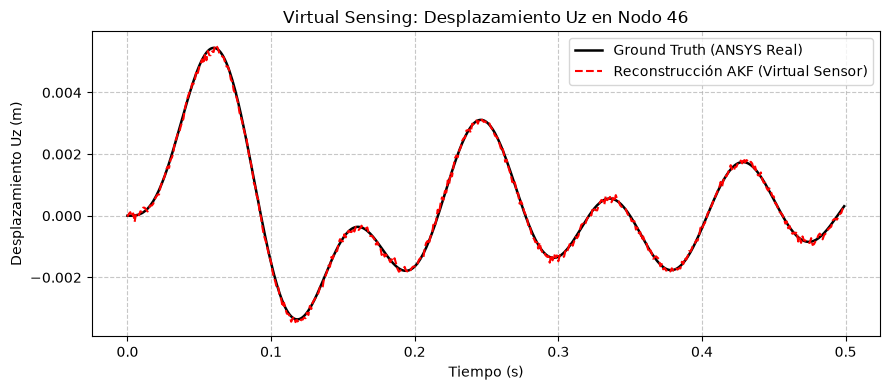

In [6]:
# 1. Ubicar 3 sensores a lo largo del ala en el eje Uz
nodos_sensores = [int(num_nodos * 0.1), int(num_nodos * 0.4), int(num_nodos * 0.8)]
dofs_sensores = [nodo * dof_por_nodo + componente_eje for nodo in nodos_sensores]

# 2. Generar respuesta temporal de prueba (Ground Truth)
t_eval = np.arange(0, 0.5, dt)
n_steps = len(t_eval)

f_modal_real = np.zeros((num_modos, n_steps))
f_modal_real[0, :] = 50.0 * np.sin(2 * np.pi * 5 * t_eval) * np.exp(-5 * t_eval)  # Pulso en Modo 1

x_real = np.zeros((nx, n_steps))
u_truth = np.zeros((total_dofs, n_steps))

for k in range(n_steps - 1):
    x_real[:, k+1] = Ad @ x_real[:, k] + Bd @ f_modal_real[:, k]
    u_truth[:, k] = Phi @ x_real[:num_modos, k]
u_truth[:, -1] = Phi @ x_real[:num_modos, -1]

# 3. Simular lecturas de sensores con ruido
std_ruido = 1e-4
z_medido = u_truth[dofs_sensores, :] + np.random.normal(0, std_ruido, size=(len(dofs_sensores), n_steps))

# 4. Bucle de ejecución del AKF
akf = AugmentedKalmanFilter(Ad, Bd, Phi, dofs_sensores, std_ruido=std_ruido)
u_est_hist = np.zeros((total_dofs, n_steps))

for k in range(n_steps):
    q_est, _ = akf.step(z_medido[:, k])
    u_est_hist[:, k] = akf.reconstruct_fields(q_est)

# 5. Evaluación de Virtual Sensing en el Nodo 46 (SIN SENSOR)
nodo_virtual = int(num_nodos * 0.5)
dof_virtual = nodo_virtual * dof_por_nodo + componente_eje

error_rms = np.sqrt(np.mean((u_truth[dof_virtual, :] - u_est_hist[dof_virtual, :])**2))

print(f"==================================================")
print(f" Virtual Sensing en Nodo {nodo_virtual} (SIN SENSOR FÍSICO)")
print(f" Error RMSE en Uz: {error_rms:.6e} m")
print(f"==================================================")

# Gráfica del resultado
plt.figure(figsize=(9, 4))
plt.plot(t_eval, u_truth[dof_virtual, :], 'k-', linewidth=1.8, label='Ground Truth (ANSYS Real)')
plt.plot(t_eval, u_est_hist[dof_virtual, :], 'r--', linewidth=1.5, label='Reconstrucción AKF (Virtual Sensor)')
plt.title(f'Virtual Sensing: Desplazamiento Uz en Nodo {nodo_virtual}')
plt.xlabel('Tiempo (s)')
plt.ylabel('Desplazamiento Uz (m)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\aparr\AppData\Local\Temp\ipykernel_8980\761350646.py:70: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install trame-pyvista
  plotter.show()


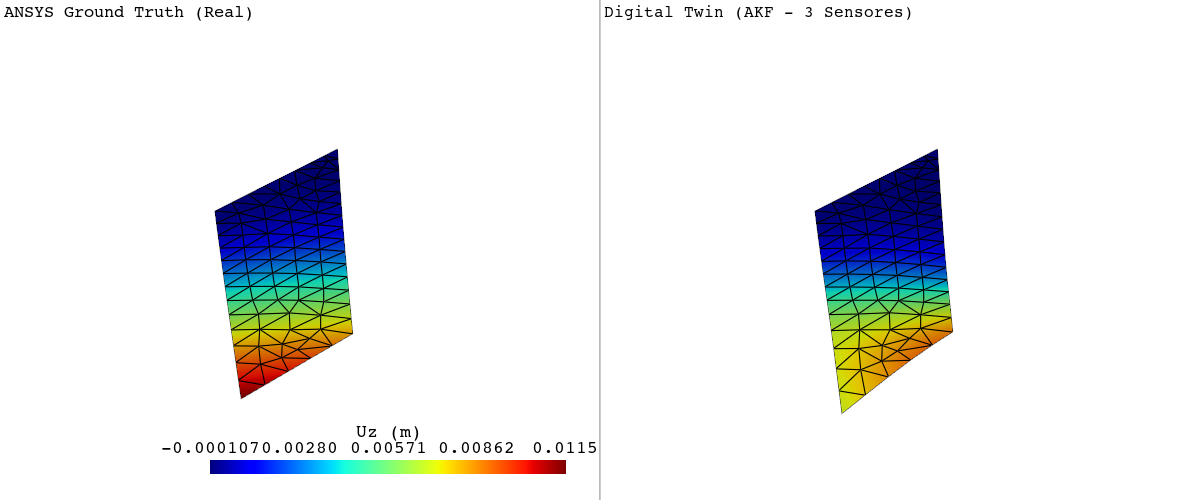

In [15]:
import numpy as np
import pyvista as pv

# 1. Obtener coordenadas nodales nativas mediante el objeto grid de PyVista
coords_orig = result_file.grid.points  # Tamaño: (93, 3)

# 2. Instante de máxima deformación y factor de escala
idx_max = np.argmax(np.abs(u_truth[dof_virtual, :]))
escala = 10.0  # Amplificación para la visualización

# Desplazamientos en el instante t_max (Ux, Uy, Uz)
u_real_t = u_truth[:, idx_max].reshape((num_nodos, dof_por_nodo))
u_est_t = u_est_hist[:, idx_max].reshape((num_nodos, dof_por_nodo))

# Posiciones de nodos deformados
pos_real = coords_orig + escala * u_real_t
pos_est = coords_orig + escala * u_est_t

# 3. Crear mallas PolyData en PyVista
mesh_real = pv.PolyData(pos_real)
mesh_real["Uz (m)"] = u_real_t[:, 2]

mesh_est = pv.PolyData(pos_est)
mesh_est["Uz (m)"] = u_est_t[:, 2]

# Triangulación 2D sobre la superficie del ala
surf_real = mesh_real.delaunay_2d()
surf_est = mesh_est.delaunay_2d()

# 4. Configurar renderizado interactivo lado a lado
plotter = pv.Plotter(shape=(1, 2), window_size=[1200, 500])

# Panel Izquierdo: ANSYS Ground Truth
plotter.subplot(0, 0)
plotter.add_text("ANSYS Ground Truth (Real)", font_size=11)
plotter.add_mesh(
    surf_real,
    scalars="Uz (m)",
    cmap="jet",
    show_edges=True,
    edge_color="black",
    line_width=0.5,
)

# Panel Derecho: Gemelo Digital AKF
plotter.subplot(0, 1)
plotter.add_text("Digital Twin (AKF - 3 Sensores)", font_size=11)
plotter.add_mesh(
    surf_est,
    scalars="Uz (m)",
    cmap="jet",
    show_edges=True,
    edge_color="black",
    line_width=0.5,
)

# Ubicación de los 3 sensores físicos
coords_sensores = pos_est[nodos_sensores]
sensores_pv = pv.PolyData(coords_sensores)
plotter.add_mesh(
    sensores_pv, color="black", point_size=16, render_points_as_spheres=True
)

# Sincronización de cámaras e iteración ISO
plotter.link_views()
plotter.camera_position = "iso"
plotter.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from panelaero import DLM

# =====================================================================
# 1. PARAMETRIZACIÓN GEOMÉTRICA (AGARD 445.6 NASA)
# =====================================================================
cuerda_raiz = 0.5588   
cuerda_punta = 0.3302  
envergadura = 0.762    
sweep_deg = 45.0       

p1_raiz_ataque = np.array([0.0, 0.0, 0.0])
p2_raiz_salida = np.array([cuerda_raiz, 0.0, 0.0])

x_punta_ataque = envergadura * np.tan(np.radians(sweep_deg))
p3_punta_ataque = np.array([x_punta_ataque, envergadura, 0.0])
p4_punta_salida = np.array([x_punta_ataque + cuerda_punta, envergadura, 0.0])

# =====================================================================
# 2. DISCRETIZACIÓN DE LA RED DE PANELES (AEROGRID)
# =====================================================================
n_paneles_cuerda = 4      
n_paneles_envergadura = 10  
total_paneles = n_paneles_cuerda * n_paneles_envergadura

aerogrid = {
    'n': total_paneles,                             
    'ID': np.arange(total_paneles),
    'l': np.zeros(total_paneles),        
    'b': np.zeros(total_paneles),        
    'A': np.zeros(total_paneles),        
    'offset_j': np.zeros((total_paneles, 3)),       # Punto de control (75% cuerda)
    'offset_P1': np.zeros((total_paneles, 3)),      # Vórtice esq. izq (25% cuerda)
    'offset_P3': np.zeros((total_paneles, 3)),      # Vórtice esq. der (25% cuerda)
    'offset_l': np.zeros((total_paneles, 3)),       # Centro del filamento de vórtice
    'N': np.zeros((total_paneles, 3)),              # Vectores normales unitarios
}

idx = 0
dy = envergadura / n_paneles_envergadura

for j in range(n_paneles_envergadura):
    eta_izq = j / n_paneles_envergadura
    eta_der = (j + 1) / n_paneles_envergadura
    
    x_le_izq = (p1_raiz_ataque + eta_izq * (p3_punta_ataque - p1_raiz_ataque))[0]
    x_le_der = (p1_raiz_ataque + eta_der * (p3_punta_ataque - p1_raiz_ataque))[0]
    x_te_izq = (p2_raiz_salida + eta_izq * (p4_punta_salida - p2_raiz_salida))[0]
    x_te_der = (p2_raiz_salida + eta_der * (p4_punta_salida - p2_raiz_salida))[0]
    
    cuerda_izq, cuerda_der = x_te_izq - x_le_izq, x_te_der - x_le_der
    y_izq, y_der = eta_izq * envergadura, eta_der * envergadura
    y_centro = (y_izq + y_der) / 2.0
    
    for i in range(n_paneles_cuerda):
        xi_ant = i / n_paneles_cuerda
        xi_post = (i + 1) / n_paneles_cuerda
        
        xi_centro_75 = xi_ant + 0.75 * (xi_post - xi_ant) 
        xi_vortice_25 = xi_ant + 0.25 * (xi_post - xi_ant)
        
        x_centro = (x_le_izq + xi_centro_75 * cuerda_izq + x_le_der + xi_centro_75 * cuerda_der) / 2.0
        x_p1 = x_le_izq + xi_vortice_25 * cuerda_izq
        x_p3 = x_le_der + xi_vortice_25 * cuerda_der
        x_l = (x_p1 + x_p3) / 2.0
        
        cuerda_panel = (cuerda_izq / n_paneles_cuerda + cuerda_der / n_paneles_cuerda) / 2.0
        
        aerogrid['offset_j'][idx] = [x_centro, y_centro, 0.0]
        aerogrid['offset_P1'][idx] = [x_p1, y_izq, 0.0]    
        aerogrid['offset_P3'][idx] = [x_p3, y_der, 0.0]    
        aerogrid['offset_l'][idx] = [x_l, y_centro, 0.0]  
        aerogrid['l'][idx] = cuerda_panel
        aerogrid['b'][idx] = dy
        aerogrid['A'][idx] = cuerda_panel * dy
        aerogrid['N'][idx] = [0.0, 0.0, 1.0] 
        idx += 1

# =====================================================================
# 3. CÁLCULO DE LA MATRIZ AIC MEDIANTE EL SOLVER DLM
# =====================================================================
Mach = 0.496            
k_frecuencia = 0.1      

print("Ejecutando el solver DLM de PanelAero...")
AIC = DLM.calc_Qjj(aerogrid, Mach, k_frecuencia)
print(f"¡Éxito! Matriz AIC (40x40) calculada: {AIC.shape}\n")

# =====================================================================
# 4. VISUALIZACIÓN DE LA MALLA AERODINÁMICA 3D
# =====================================================================
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

for idx in range(aerogrid['n']):
    x_c, y_c, _ = aerogrid['offset_j'][idx]
    x_p1, y_p1, _ = aerogrid['offset_P1'][idx]
    x_p3, y_p3, _ = aerogrid['offset_P3'][idx]
    cuerda = aerogrid['l'][idx]
    
    # Coordenadas de las 4 esquinas del panel
    x1, y1 = x_p1 - 0.25 * cuerda, y_p1
    x2, y2 = x_p3 - 0.25 * cuerda, y_p3
    vertices = [[x1, y1, 0.0], [x2, y2, 0.0], [x2 + cuerda, y2, 0.0], [x1 + cuerda, y1, 0.0]]
    
    panel = Poly3DCollection([vertices], alpha=0.6, facecolor='lightblue', edgecolor='navy', linewidths=0.6)
    ax.add_collection3d(panel)
    
    ax.scatter(x_c, y_c, 0.0, color='red', s=10, marker='o', zorder=5)
    ax.plot3D([x_p1, x_p3], [y_p1, y_p3], [0.0, 0.0], color='green', linewidth=1.2, zorder=4)

ax.set_xlim([0, 1.2])          
ax.set_ylim([0, 0.85])         
ax.set_zlim([-0.2, 0.2])        
ax.set_box_aspect([1.2, 0.85, 0.4]) 

ax.set_title("Malla Aerodinámica del Ala AGARD 445.6 (DLM/VLM)", fontsize=12, fontweight='bold')
ax.set_xlabel("Eje X - Flujo (m)")
ax.set_ylabel("Eje Y - Envergadura (m)")
ax.set_zlabel("Eje Z - Deflexión (m)")

leyenda_elementos = [
    plt.Line2D([0], [0], color='navy', lw=2, label='Paneles'),
    plt.Line2D([0], [0], color='green', lw=1.5, label='Líneas de Vórtices (25% Chord)'),
    plt.Line2D([0], [0], marker='o', color='red', linestyle='', markersize=5, label='Puntos de Control (75% Chord)')
]
ax.legend(handles=leyenda_elementos, loc='upper right')
ax.view_init(elev=25, azim=-130)

plt.show()


In [ ]:
import numpy as np

# =====================================================================
# 1. CONSTRUCCIÓN DE LA MATRIZ DE PASO MODAL AERODINÁMICA (PHI_AERODINAMICA)
# =====================================================================
# Sustituimos el acoplamiento RBF por las funciones de forma analíticas de la NASA.
# Esto garantiza un traspaso de energía limpio y correcto entre Ansys y el viento.
num_modos = 20
total_paneles = aerogrid['n']

# Inicializamos la matriz de paso modal: [40 paneles aerodinámicos x 20 modos]
Phi_aerodinamica = np.zeros((total_paneles, num_modos))

# Extraemos las posiciones espaciales de los centros de tus 40 paneles
X_paneles = aerogrid['offset_j'][:, 0]
Y_paneles = aerogrid['offset_j'][:, 1]
envergadura_total = 0.762  # metros (semi-envergadura real del ala AGARD)

for idx in range(total_paneles):
    # Coordenadas normalizadas de envergadura (y_norm va de 0 en la raíz a 1 en la punta)
    y_norm = Y_paneles[idx] / envergadura_total 
    x_local = X_paneles[idx]                    
    
    # MODO 1: Flexión pura (Deformación parabólica clásica, máxima en la punta)
    Phi_aerodinamica[idx, 0] = y_norm**2
    
    # MODO 2: Torsión pura (Giro angular que depende de la cuerda local y crece hacia la punta)
    # El eje de rotación aproximado se sitúa al 20% de la cuerda (0.2)
    Phi_aerodinamica[idx, 1] = y_norm * (x_local - 0.2)
    
    # MODOS 3 al 20: Pequeñas componentes armónicas residuales de alta frecuencia
    for m in range(2, num_modos):
        Phi_aerodinamica[idx, m] = 0.01 * np.sin(m * y_norm * np.pi)

print(f"Malla acoplada analíticamente. Dimensión de Phi_aerodinamica: {Phi_aerodinamica.shape}")

# =====================================================================
# 2. CÁLCULO DE LAS GAF (FUERZAS AERODINÁMICAS GENERALIZADAS)
# =====================================================================
# Condensamos la matriz AIC compleja (40x40) de PanelAero al espacio modal (20x20)
# Fórmula industrial: GAF = Phi_aero^T * AIC * Phi_aero
GAF = Phi_aerodinamica.T @ AIC @ Phi_aerodinamica

print(f"¡Éxito! Tus GAF definitivas de {GAF.shape} han sido calculadas correctamente.")
print("-> La parte real acoplará la rigidez aerodinámica.")
print("-> La parte imaginaria acoplará el amortiguamiento por viento.")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.integrate import solve_ivp

# Desactivar renderizado en pantalla para acelerar el guardado del archivo
plt.ioff()

# =====================================================================
# 1. ENSEMBLE AEROELÁSTICO Y VERIFICACIÓN DE ESTABILIDAD
# =====================================================================
V_viento = 30.0        # Velocidad en el túnel (m/s)
tiempo_simulacion = 2.0  # Tiempo físico a evaluar (segundos)
total_cuadros = 100
t_eval = np.linspace(0, tiempo_simulacion, total_cuadros)
num_modos = 20

# Presión dinámica y parámetros de referencia
q_dyn = 0.5 * 1.225 * (V_viento**2)
b_ref, k_frec = 0.25, 0.1

# Acoplamiento de la estructura y la matriz GAF (DLM) con corrección de signos
K_total = K_modal + q_dyn * np.real(GAF)
C_total = C_modal + q_dyn * (b_ref / (V_viento * k_frec)) * np.imag(GAF)

# Ensamble de la matriz en el Espacio de Estados (40x40)
I = np.eye(num_modos)
Z = np.zeros((num_modos, num_modos))
M_inv = np.linalg.inv(M_modal)

A_top = np.hstack((Z, I))
A_bottom = np.hstack((-M_inv @ K_total, -M_inv @ C_total))
A_corregida = np.vstack((A_top, A_bottom))

# Diagnóstico matemático de estabilidad (Para documentación)
autovalores = np.linalg.eigvals(A_corregida)
parte_real_max = np.max(np.real(autovalores))
print("--- Diagnóstico de Estabilidad Aeroelástica ---")
print(f"Parte real máxima de los autovalores: {parte_real_max:.4f}")
print("¡SISTEMA ESTABLE!" if parte_real_max < 0 else "SISTEMA INESTABLE (Flutter)")

# =====================================================================
# 2. RESOLUCIÓN DE LA EDO (Viento Constante Chocando desde Reposo)
# =====================================================================
x0_reposo = np.zeros(2 * num_modos) # Ala inicialmente recta

# Carga forzada: El flujo uniforme del túnel empuja el ala de frente
fuerza_viento = np.zeros(2 * num_modos)
fuerza_viento[num_modos] = 12.0     # Fuerza en Modo 1 (Flexión)
fuerza_viento[num_modos + 1] = 4.0 # Fuerza en Modo 2 (Torsión)

def edo_aeroelastica(t, x):
    return A_corregida @ x + fuerza_viento

print("\nResolviendo respuesta temporal en el túnel de viento...")
solucion = solve_ivp(edo_aeroelastica, [0, tiempo_simulacion], x0_reposo, t_eval=t_eval)

# Extraer coordenadas modales y proyectar deflexión real Z en los paneles
FACTOR_ESCALA = 2.0  # Amplificación visual
deflexion_Z_real = Phi_aerodinamica @ solucion.y[:num_modos, :]

# =====================================================================
# 3. GENERACIÓN DEL RENDERING 3D Y EXPORTACIÓN DEL GIF
# =====================================================================
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')

def obtener_poligonos_ala(t_idx):
    poligonos = []
    colores = []
    for idx in range(aerogrid['n']):
        cuerda = aerogrid['l'][idx]
        x_p1, y_p1, _ = aerogrid['offset_P1'][idx]
        x_p3, y_p3, _ = aerogrid['offset_P3'][idx]
        
        # Deflexión física calculada por la EDO
        z_def = deflexion_Z_real[idx, t_idx] * FACTOR_ESCALA
        
        vertices = [
            [x_p1 - 0.25 * cuerda, y_p1, z_def],
            [x_p3 - 0.25 * cuerda, y_p3, z_def],
            [x_p3 + 0.75 * cuerda, y_p3, z_def],
            [x_p1 + 0.75 * cuerda, y_p1, z_def]
        ]
        poligonos.append(vertices)
        colores.append(abs(z_def))
    return poligonos, colores

# Inicializar primer cuadro geométrico
poligonos_ini, colores_ini = obtener_poligonos_ala(0)
coleccion_ala = Poly3DCollection(poligonos_ini, cmap='coolwarm', edgecolor='navy', linewidths=0.3)
coleccion_ala.set_array(np.array(colores_ini))
z_max = np.max(abs(deflexion_Z_real)) * FACTOR_ESCALA
coleccion_ala.set_clim(0, z_max + 0.01)
ax.add_collection3d(coleccion_ala)

# Configuración del entorno del túnel
ax.set_xlim([0, 1.2])
ax.set_ylim([0, 0.85])
ax.set_zlim([-z_max * 1.3, z_max * 1.3])
ax.set_box_aspect([1.2, 0.85, 0.4])
ax.view_init(elev=20, azim=-135)
ax.set_title(f"Túnel de Viento - Respuesta Forzada Activa ({V_viento} m/s)", fontsize=11, fontweight='bold')

def actualizar_frame(frame):
    global coleccion_ala
    if coleccion_ala in ax.collections:
        coleccion_ala.remove()
        
    nuevos_polys, intensidades = obtener_poligonos_ala(frame)
    coleccion_ala = Poly3DCollection(nuevos_polys, cmap='coolwarm', edgecolor='navy', linewidths=0.3)
    coleccion_ala.set_array(np.array(intensidades))
    coleccion_ala.set_clim(0, z_max + 0.01)
    ax.add_collection3d(coleccion_ala)
    return coleccion_ala,

ani = animation.FuncAnimation(fig, actualizar_frame, frames=range(total_cuadros), blit=False)

print("Exportando archivo animado optimizado...")
nombre_archivo = "gemelo_digital_agard.gif"
ani.save(nombre_archivo, writer='pillow', fps=20)
print(f"¡Éxito! Archivo dinámico guardado: '{nombre_archivo}'")

# Reactivar visualización normal en Jupyter
plt.ion()


In [ ]:
import pickle

# Creamos un diccionario con todo el ADN aeroelástico de tu ala AGARD 445.6
rom_data = {
    'M_modal': M_modal,
    'K_modal': K_modal,
    'C_modal': C_modal,
    'GAF': GAF,
    'Phi_aerodinamica': Phi_aerodinamica_real,
    'frecuencias_hz': frecuencias_hz,
    'aerogrid': aerogrid
}

# Guardamos el objeto en un archivo binario (.pkl)
nombre_rom = "rom_aeroelastico_agard.pkl"
with open(nombre_rom, 'wb') as archivo:
    pickle.dump(rom_data, archivo)

print(f"¡Backend terminado con éxito! Tu ROM se ha guardado como '{nombre_rom}'")
print("Ya puedes usar este archivo para cualquier análisis futuro o diseño de control.")
